# A1 — Corpus Exploration: Agri-Bot (Bangla Agricultural Manuals)

This notebook explores our corpus of three 1930s–40s Bangla agricultural manuals
(**Krishi-Bigyan**, **Krishi-Darpan**, **Bharater-Krishi-Babyasthar-Parichay**),
sourced from the Internet Archive.

We now have Gemini-derived ground-truth (GT) transcriptions for every page, organised as:

```
data/
├── raw/                  # original PDFs (used ONLY for the blank-page pass below)
├── pages/<book>/page-NNN.png        # pre-split page images (what we actually work with)
├── blank/<book>/...                 # pages that were pulled out as blank/non-content
├── ground-truth-ocr/<book>/page-NNN.txt   # Gemini GT transcription per page
├── provenance.md
└── README.md
```

**What this notebook does, in order:**

1. **Blank-page detection direct from the raw PDFs** — reproduces the original filtering
   pass (foreground-pixel-density threshold) *in memory*, without re-saving anything,
   since split pages already live in `data/pages/`.
2. **Corpus inventory** built from `data/pages/` + `data/ground-truth-ocr/` (page counts,
   disk size, word/char counts, vocabulary, script statistics, content-flag heuristics).
3. **Scan-quality metrics** (blur, contrast, skew, stroke integrity, blob area) computed
   directly on the split page images.
4. **Train/val/test split & leakage check** (split by document, not by page).
5. **Three example pages** (image + GT text side by side), matching Section 3 of the A1 form.
6. **OCR tool bake-off** — Tesseract vs EasyOCR vs PaddleOCR vs Surya OCR, scored against
   the Gemini GT with CER/WER (`jiwer`).
7. **Preprocessing sweep** on the winning OCR tool — deskew, denoise, CLAHE+Otsu, margin
   crop, morphological stroke-repair, unsharp mask — individually and combined, per book.
8. **Recommendations** — best preprocessing recipe per book, to carry into Stage 1 (Ingest
   + Enhance) of the pipeline.

## 0. Setup

In [7]:
import os
import re
import json
import random
import unicodedata
import subprocess
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)

plt.rcParams["figure.dpi"] = 100
matplotlib.rcParams["axes.unicode_minus"] = False

# --- Bengali-capable font for matplotlib titles/labels (optional, nice to have) ---
# If you have a Bengali font (e.g. Noto Sans Bengali) installed, point to it here so
# Bangla titles/labels don't render as boxes. Safe to leave as None.
BENGALI_FONT_PATH = None  # e.g. "/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf"
if BENGALI_FONT_PATH and Path(BENGALI_FONT_PATH).exists():
    from matplotlib import font_manager
    font_manager.fontManager.addfont(BENGALI_FONT_PATH)
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=BENGALI_FONT_PATH).get_name()

DATA_DIR   = Path("../data")
RAW_DIR    = DATA_DIR / "raw"
PAGES_DIR  = DATA_DIR / "pages"
BLANK_DIR  = DATA_DIR / "blank"
GT_DIR     = DATA_DIR / "ground-truth-ocr"

PDF_FILES = {
    "Krishi-Bigyan": RAW_DIR / "Krishi-Bigyan.pdf",
    "Krishi-Darpan": RAW_DIR / "Krishi-Darpan.pdf",
    "Bharater-Krishi-Babyasthar-Parichay": RAW_DIR / "Bharater-Krishi-Babyasthar-Parichay.pdf",
}

BOOKS = list(PDF_FILES.keys())

# Document-level split (no page ever crosses a split -- see Section 4 of this notebook)
TRAIN_VAL_BOOKS = ["Krishi-Bigyan", "Bharater-Krishi-Babyasthar-Parichay"]
TEST_BOOKS      = ["Krishi-Darpan"]

for name, path in PDF_FILES.items():
    status = "OK" if path.exists() else "MISSING"
    size = f"{path.stat().st_size / 1e6:.2f} MB" if path.exists() else "-"
    print(f"[{status:7s}] {name:40s} {size}")

for d in [PAGES_DIR, BLANK_DIR, GT_DIR]:
    print(f"[{'OK' if d.exists() else 'MISSING':7s}] {d}")

[OK     ] Krishi-Bigyan                            16.96 MB
[OK     ] Krishi-Darpan                            8.13 MB
[OK     ] Bharater-Krishi-Babyasthar-Parichay      12.89 MB
[OK     ] ../data/pages
[OK     ] ../data/blank
[OK     ] ../data/ground-truth-ocr


## 1. Blank-page detection, direct from the raw PDFs

This mirrors the **actual** blank-page filter used in Stage 1 ingest (`src/.../ingest.py
run()`), not a re-derived approximation — a naive "foreground pixel density < 2%" check
was tried first and **overestimates** blanks badly, because plenty of genuine content pages
(chapter dividers, sparse headings, generous 1930s margins) sit well under 2% ink coverage
and get wrongly swept in. Three fixes, taken straight from the pipeline code:

1. **Denoise before counting** — `cv2.MORPH_OPEN` (2×2 kernel) removes 1–2px scan speckle
   before thresholding, so noise doesn't get counted as "ink".
2. **Only count real blobs** — connected components below `min_blob_area` (15px) are
   dropped entirely from the ink-pixel sum, instead of counting every raw foreground pixel.
3. **Much stricter ratio + a second signal** — `ink_ratio_threshold = 0.002` (0.2%, not 2%),
   OR'd with `blob_count < min_blob_count` (3) — a page with a couple of large real ink
   blobs but low total area (e.g. a single heading) is *not* blank; a page with almost no
   distinguishable components is.

We run this **directly against `data/raw/*.pdf`**, in memory, at a modest DPI (150) — we
don't write anything to disk here since the already-split, already-filtered pages live in
`data/pages/` and the pages actually pulled out live in `data/blank/`. The point of
re-deriving it here (rather than just trusting `data/blank/`) is to (a) document,
reproducibly, how blank pages are identified — auditable, ties to our Robust/Reliable NFR
— and (b) confirm the ingest-stage output agrees with what's on disk.

In [8]:
from pdf2image import convert_from_path

BLANK_DPI = 150

# Same defaults as src/.../ingest.py's run(): min_blob_area=15, ink_ratio_threshold=0.002,
# min_blob_count=3. Keep these in sync with configs/task.yaml's `ingest` block rather than
# hand-copying magic numbers -- if the pipeline config changes, this notebook should too.
MIN_BLOB_AREA = 15
INK_RATIO_THRESHOLD = 0.002
MIN_BLOB_COUNT = 3

def page_stats(pil_img: Image.Image, min_blob_area: int = MIN_BLOB_AREA) -> dict:
    '''Same logic as ingest.py::_page_stats, but operating on an in-memory PIL image
    instead of a path on disk (we never save the raw-PDF renders here).'''
    gray = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    _num_labels, _labels, stats, _centroids = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    real_blobs = areas[areas >= min_blob_area]
    total_pixels = gray.shape[0] * gray.shape[1]
    ink_ratio = float(real_blobs.sum()) / total_pixels if total_pixels else 0.0
    return {"blob_count": int(len(real_blobs)), "ink_ratio": ink_ratio}

def is_blank(stats: dict, min_blob_count: int = MIN_BLOB_COUNT,
             ink_ratio_threshold: float = INK_RATIO_THRESHOLD) -> bool:
    '''Same logic as ingest.py::_is_blank.'''
    return stats["blob_count"] < min_blob_count or stats["ink_ratio"] < ink_ratio_threshold

blank_records = []
for book_name, pdf_path in PDF_FILES.items():
    if not pdf_path.exists():
        print(f"Skipping {book_name}: PDF not found at {pdf_path}")
        continue

    pages = convert_from_path(str(pdf_path), dpi=BLANK_DPI)  # list of PIL Images, in memory
    for i, pil_img in enumerate(tqdm(pages, desc=f"Blank-scan {book_name}"), start=1):
        stats = page_stats(pil_img)
        blank_records.append({
            "book": book_name,
            "page_num": i,
            "blob_count": stats["blob_count"],
            "ink_ratio": round(stats["ink_ratio"], 5),
            "is_blank_auto": is_blank(stats),
        })
        pil_img.close()  # release memory promptly; nothing is saved to disk

blank_df = pd.DataFrame(blank_records)
blank_df.to_csv("blank_page_scan_INMEMORY_not_a_data_artifact.csv", index=False)  # scratch only, not part of data/
blank_df.head()

Blank-scan Bharater-Krishi-Babyasthar-Parichay: 100%|██████████| 278/278 [00:02<00:00, 122.84it/s]


,book,page_num,blob_count,ink_ratio,is_blank_auto
0,Krishi-Bigyan,1,1,0.00437,True
1,Krishi-Bigyan,2,1,0.00437,True
2,Krishi-Bigyan,3,1,0.00437,True
3,Krishi-Bigyan,4,202,0.03620,False
4,Krishi-Bigyan,5,163,0.00507,False


In [9]:
blank_summary = (
    blank_df.groupby("book")
    .agg(pages=("page_num", "count"),
         auto_flagged_blank=("is_blank_auto", "sum"),
         mean_ink_ratio=("ink_ratio", "mean"),
         mean_blob_count=("blob_count", "mean"))
    .round(4)
)
blank_summary["pct_blank"] = (100 * blank_summary["auto_flagged_blank"] / blank_summary["pages"]).round(2)
print(f"=== Auto blank-page detection (direct from PDFs; ink_ratio<{INK_RATIO_THRESHOLD} OR blob_count<{MIN_BLOB_COUNT}) ===")
print(blank_summary.to_string())
print(f"\nTotal pages scanned: {len(blank_df)}")
print(f"Total auto-flagged blank/non-content pages: {int(blank_df['is_blank_auto'].sum())}")

=== Auto blank-page detection (direct from PDFs; ink_ratio<0.002 OR blob_count<3) ===
                                     pages  auto_flagged_blank  mean_ink_ratio  mean_blob_count  pct_blank
book                                                                                                      
Bharater-Krishi-Babyasthar-Parichay    278                  11          0.0933         458.5432       3.96
Krishi-Bigyan                          304                  10          0.0758         843.9638       3.29
Krishi-Darpan                          194                   6          0.0390         515.8505       3.09

Total pages scanned: 776
Total auto-flagged blank/non-content pages: 27


In [10]:
# Cross-check against what's actually in data/blank/: does our threshold agree with
# the pages that were pulled out at split time?
def list_blank_pagenums(book_name):
    book_blank_dir = BLANK_DIR / book_name
    if not book_blank_dir.exists():
        return set()
    nums = set()
    for p in book_blank_dir.glob("page-*.png"):
        m = re.search(r"page-(\d+)", p.stem)
        if m:
            nums.add(int(m.group(1)))
    return nums

rows = []
for book_name in BOOKS:
    saved_blank = list_blank_pagenums(book_name)
    auto_blank = set(blank_df.loc[(blank_df.book == book_name) & (blank_df.is_blank_auto), "page_num"])
    agree = saved_blank & auto_blank
    only_saved = saved_blank - auto_blank
    only_auto = auto_blank - saved_blank
    rows.append({
        "book": book_name,
        "n_saved_blank": len(saved_blank),
        "n_auto_blank": len(auto_blank),
        "agree": len(agree),
        "only_in_data/blank": len(only_saved),
        "only_flagged_by_threshold": len(only_auto),
    })
    if only_saved:
        print(f"{book_name}: pages in data/blank/ but NOT auto-flagged (check threshold / scan quality): {sorted(only_saved)}")
    if only_auto:
        print(f"{book_name}: pages auto-flagged but NOT in data/blank/ (possible near-blank/figure-only pages): {sorted(only_auto)}")

pd.DataFrame(rows)

,book,n_saved_blank,n_auto_blank,agree,only_in_data/blank,only_flagged_by_threshold
0,Krishi-Bigyan,10,10,10,0,0
1,Krishi-Darpan,6,6,6,0,0
2,Bharater-Krishi-Babyasthar-Parichay,11,11,11,0,0


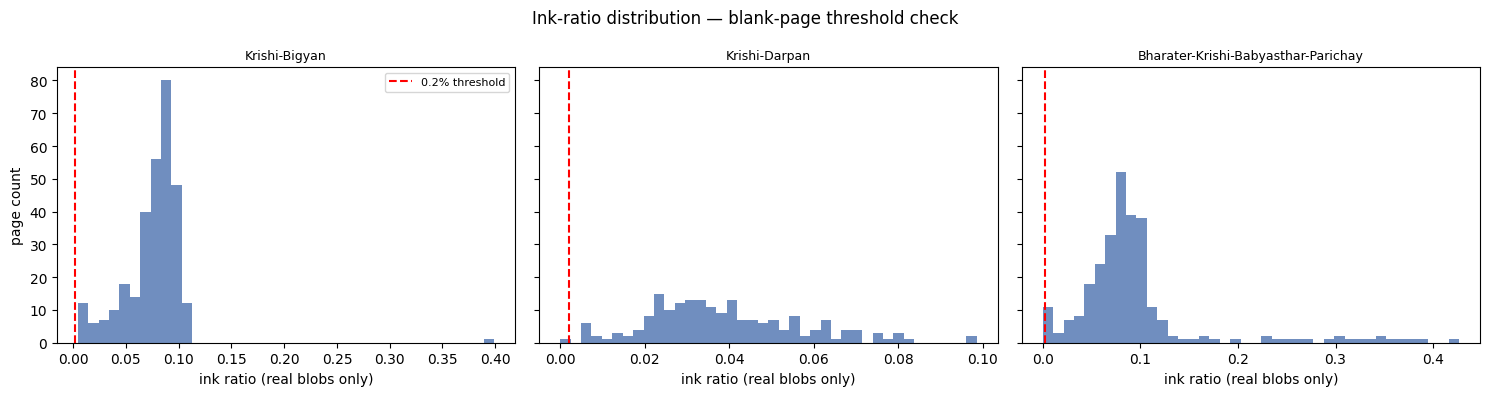

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, book_name in zip(axes, BOOKS):
    sub = blank_df[blank_df.book == book_name]
    ax.hist(sub.ink_ratio, bins=40, color="#4C72B0", alpha=0.8)
    ax.axvline(INK_RATIO_THRESHOLD, color="red", linestyle="--", label=f"{INK_RATIO_THRESHOLD:.1%} threshold")
    ax.set_title(book_name, fontsize=9)
    ax.set_xlabel("ink ratio (real blobs only)")
axes[0].set_ylabel("page count")
axes[0].legend(fontsize=8)
fig.suptitle("Ink-ratio distribution — blank-page threshold check")
plt.tight_layout()
plt.show()

## 2. Corpus inventory — split pages + ground-truth text

From here on we work exclusively with `data/pages/` (images) and `data/ground-truth-ocr/`
(Gemini GT text), never re-deriving pages from the PDFs again.

In [12]:
def gt_path_for(book, page_num):
    return GT_DIR / book / f"page-{page_num:03d}.txt"

def page_img_path_for(book, page_num):
    return PAGES_DIR / book / f"page-{page_num:03d}.png"

def is_known_blank(book, page_num):
    return (BLANK_DIR / book / f"page-{page_num:03d}.png").exists()

records = []
for book in BOOKS:
    book_page_dir = PAGES_DIR / book
    if not book_page_dir.exists():
        print(f"Missing pages dir for {book}: {book_page_dir}")
        continue
    img_paths = sorted(book_page_dir.glob("page-*.png"))
    for img_path in img_paths:
        m = re.search(r"page-(\d+)", img_path.stem)
        page_num = int(m.group(1))
        gtp = gt_path_for(book, page_num)
        gt_text = gtp.read_text(encoding="utf-8").strip() if gtp.exists() else None
        records.append({
            "book": book,
            "page_num": page_num,
            "page_id": f"{book}_p{page_num:03d}",
            "img_path": str(img_path),
            "img_size_kb": round(img_path.stat().st_size / 1024, 1),
            "has_gt": gtp.exists(),
            "gt_char_count": len(gt_text) if gt_text else 0,
            "gt_word_count": len(gt_text.split()) if gt_text else 0,
            "is_known_blank": is_known_blank(book, page_num),
        })

corpus_df = pd.DataFrame(records).sort_values(["book", "page_num"]).reset_index(drop=True)
print(f"Total split pages found: {len(corpus_df)}")
corpus_df.head()

Total split pages found: 749


,book,page_num,page_id,img_path,img_size_kb,has_gt,gt_char_count,gt_word_count,is_known_blank
0,Bharater-Krishi-Babyasthar-Parichay,4,Bharater-Krishi-Babyasthar-Parichay_p004,../data/pages/Bharater-Krishi-Babyasthar-Paric...,36.7,True,125,15,False
1,Bharater-Krishi-Babyasthar-Parichay,6,Bharater-Krishi-Babyasthar-Parichay_p006,../data/pages/Bharater-Krishi-Babyasthar-Paric...,187.2,True,115,21,False
2,Bharater-Krishi-Babyasthar-Parichay,8,Bharater-Krishi-Babyasthar-Parichay_p008,../data/pages/Bharater-Krishi-Babyasthar-Paric...,99.6,True,653,98,False
3,Bharater-Krishi-Babyasthar-Parichay,9,Bharater-Krishi-Babyasthar-Parichay_p009,../data/pages/Bharater-Krishi-Babyasthar-Paric...,92.1,True,713,103,False
4,Bharater-Krishi-Babyasthar-Parichay,10,Bharater-Krishi-Babyasthar-Parichay_p010,../data/pages/Bharater-Krishi-Babyasthar-Paric...,178.2,True,1332,210,False


In [13]:
inventory = (
    corpus_df.groupby("book")
    .agg(pages=("page_num", "count"),
         known_blank=("is_known_blank", "sum"),
         pages_with_gt=("has_gt", "sum"),
         total_disk_kb=("img_size_kb", "sum"),
         total_gt_words=("gt_word_count", "sum"),
         total_gt_chars=("gt_char_count", "sum"))
    .assign(total_disk_mb=lambda d: (d.total_disk_kb / 1024).round(2))
    .drop(columns="total_disk_kb")
)
inventory.loc["TOTAL"] = inventory.sum(numeric_only=True)
print("=== Corpus inventory (from data/pages + data/ground-truth-ocr) ===")
print(inventory.to_string())

total_pages = int(inventory.loc["TOTAL", "pages"])
total_words = int(inventory.loc["TOTAL", "total_gt_words"])
print(f"\nMeets >= 300 pages: {total_pages >= 300}  ({total_pages} pages)")
print(f"Meets >= 60,000 words (Gemini GT, exact this time, not sampled): {total_words >= 60000}  ({total_words} words)")

=== Corpus inventory (from data/pages + data/ground-truth-ocr) ===
                                     pages  known_blank  pages_with_gt  total_gt_words  total_gt_chars  total_disk_mb
book                                                                                                                 
Bharater-Krishi-Babyasthar-Parichay  267.0          0.0          267.0         45056.0        280941.0          44.02
Krishi-Bigyan                        294.0          0.0          294.0         58589.0        397972.0          35.78
Krishi-Darpan                        188.0          0.0          188.0         34345.0        208556.0          15.62
TOTAL                                749.0          0.0          749.0        137990.0        887469.0          95.42

Meets >= 300 pages: True  (749 pages)
Meets >= 60,000 words (Gemini GT, exact this time, not sampled): True  (137990 words)


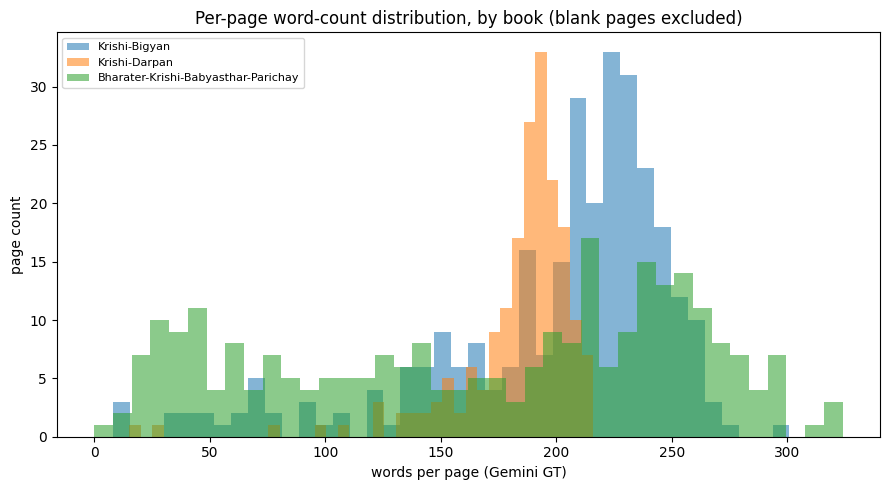

                                     count   mean   std   min    25%    50%    75%    max
book                                                                                     
Bharater-Krishi-Babyasthar-Parichay  267.0  168.7  87.4   0.0   88.5  192.0  243.0  324.0
Krishi-Bigyan                        294.0  199.3  54.0   8.0  181.2  216.0  233.8  301.0
Krishi-Darpan                        188.0  182.7  27.5  15.0  177.0  190.0  197.2  216.0


In [14]:
# Content-page word count distribution (excludes known-blank pages)
content_df = corpus_df[~corpus_df.is_known_blank]

fig, ax = plt.subplots(figsize=(9, 5))
for book in BOOKS:
    sub = content_df[content_df.book == book]
    ax.hist(sub.gt_word_count, bins=40, alpha=0.55, label=book)
ax.set_xlabel("words per page (Gemini GT)")
ax.set_ylabel("page count")
ax.set_title("Per-page word-count distribution, by book (blank pages excluded)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(content_df.groupby("book")["gt_word_count"].describe().round(1).to_string())

## 3. Script & content statistics from the ground-truth text

Now that we have real (Gemini-verified) transcriptions instead of a 45-page Tesseract
sample, we can measure script composition and content-type signals precisely instead of
estimating them.

In [17]:
import re
import pandas as pd
from tqdm.auto import tqdm


# ============================================================
# Unicode ranges of interest
# ============================================================

BENGALI_RANGE = (0x0980, 0x09FF)
BENGALI_DIGITS = set("০১২৩৪৫৬৭৮৯")
LATIN_RANGE = (0x0041, 0x007A)


def char_class_counts(text):
    n_bengali = 0
    n_latin = 0
    n_digit_bn = 0
    n_digit_ascii = 0
    n_other = 0

    for ch in text:
        cp = ord(ch)

        # Bengali Unicode block
        if BENGALI_RANGE[0] <= cp <= BENGALI_RANGE[1]:
            n_bengali += 1

            if ch in BENGALI_DIGITS:
                n_digit_bn += 1

        # ASCII Latin letters
        elif ch.isascii() and ch.isalpha():
            n_latin += 1

        # ASCII digits
        elif ch.isascii() and ch.isdigit():
            n_digit_ascii += 1

        # Everything else except whitespace
        elif not ch.isspace():
            n_other += 1

    return (
        n_bengali,
        n_latin,
        n_digit_bn,
        n_digit_ascii,
        n_other,
    )


# ============================================================
# Heuristic content detectors
# ============================================================

# ------------------------------------------------------------
# 1. Figure references
# ------------------------------------------------------------

FIGURE_RE = re.compile(
    r"(চিত্র(?:\s*নং)?|ছবি|Fig\.?|Figure)\s*[\d০-৯]*",
    re.IGNORECASE
)


# ------------------------------------------------------------
# 2. Table detection
#
# Detects:
#   - Markdown-style tables
#   - Multiple aligned rows with several columns
# ------------------------------------------------------------

MARKDOWN_TABLE_RE = re.compile(
    r"""
    ^\s*\|.*\|.*\n
    \s*\|(?:\s*:?-+:?\s*\|)+
    """,
    re.MULTILINE | re.VERBOSE
)

TABLE_HINT_RE = re.compile(
    r"""
    (?:
        ^\s*(?:\S+\s+){2,}\S+
        \n
    )
    (?:
        ^\s*(?:\S+\s+){2,}\S+
        \n?
    )+
    """,
    re.MULTILINE | re.VERBOSE
)


def has_table_hint(text):
    return bool(
        MARKDOWN_TABLE_RE.search(text)
        or TABLE_HINT_RE.search(text)
    )


# ------------------------------------------------------------
# 3. Bilingual / English terms embedded in Bengali text
#
# Particularly targets patterns such as:
#
#   (respiration)
#   (stomata)
#   (catalyst)
#   (super phosphate)
#   (bone meal)
#   (calcium phosphate)
# ------------------------------------------------------------

BILINGUAL_RE = re.compile(
    r"\([^()\n]*[A-Za-z]{2,}[^()\n]*\)"
)


# ------------------------------------------------------------
# 4. Chemical notation
#
# Designed around formulas appearing in your corpus:
#
#   H₂O
#   CO₂
#   NH₃
#   NH₄⁺
#   NO₃⁻
#   CaCO₃
#   CaSO₄
#   Ca₃(PO₄)₂
#   (NH₄)₂SO₄
#   CO(NH₂)₂
#   NH₄NO₃
#   K₂O
#   P₂O₅
#   N-P-K
# ------------------------------------------------------------

CHEM_RE = re.compile(
    r"""
    (?:
        H₂O
        | CO₂
        | NH₃
        | NH₄⁺?
        | NO₃⁻?
        | CaCO₃
        | CaSO₄
        | CaO
        | Ca\(OH\)₂
        | Ca₃\(PO₄\)₂
        | \(NH₄\)₂SO₄
        | CO\(NH₂\)₂
        | NH₄NO₃
        | K₂O
        | P₂O₅
        | N[-\s]?P[-\s]?K
    )
    """,
    re.VERBOSE
)


# ------------------------------------------------------------
# 5. Mathematical notation
#
# Designed around examples from your transcripts:
#
#   ৩ × ৩ : ১
#   ৯ : ৩ : ৩ : ১
#   ৫/৯
#   T × t = Tt
#   TT, Tt, tT, tt
#   RT, Rt, rT, rt
# ------------------------------------------------------------

MATH_RE = re.compile(
    r"""
    # Numeric arithmetic / ratios
    \d+\s*[×x÷+−\-=:]\s*\d+

    # Fractions
    |\d+\s*/\s*\d+

    # Mendelian/genetic notation
    |\b[TRtr]\s*[×x]\s*[TRtr]\b

    # Genetic factor combinations
    |\b(?:TT|Tt|tT|tt|RT|Rt|rT|rt)\b
    """,
    re.VERBOSE
)


# ------------------------------------------------------------
# 6. LaTeX detection
#
# Useful if this scan is run BEFORE your LaTeX-cleaning step.
#
# Examples:
#   $\frac{...}{...}$
#   $\text{...}$
#   \begin{aligned}
#   \left.
#   \times
# ------------------------------------------------------------

LATEX_RE = re.compile(
    r"""
    \$\$?.*?\$\$?
    |
    \\(?:
        frac
        | text
        | begin
        | end
        | left
        | right
        | times
        | cdot
        | mathbf
        | mathrm
        | sqrt
        | aligned
        | circ
    )
    """,
    re.VERBOSE | re.DOTALL
)


# ------------------------------------------------------------
# 7. Footnotes
#
# Examples:
#   ¹
#   ²
#   ³
#   *
#   †
#   ‡
# ------------------------------------------------------------

FOOTNOTE_RE = re.compile(
    r"""
    ^\s*
    (?:
        [*†‡]
        |
        [¹²³⁴⁵⁶⁷⁸⁹⁰]+
    )
    \s*
    """,
    re.MULTILINE | re.VERBOSE
)


# ============================================================
# Scan all GT text
# ============================================================

rows = []

for _, row in tqdm(
    content_df.iterrows(),
    total=len(content_df),
    desc="Scanning GT text"
):

    gtp = gt_path_for(row.book, row.page_num)

    if gtp.exists():
        text = gtp.read_text(encoding="utf-8")
    else:
        text = ""

    # --------------------------------------------------------
    # Character statistics
    # --------------------------------------------------------

    (
        n_beng,
        n_lat,
        n_dig_bn,
        n_dig_ascii,
        n_other,
    ) = char_class_counts(text)

    # --------------------------------------------------------
    # Content flags
    # --------------------------------------------------------

    has_figure = bool(FIGURE_RE.search(text))
    has_table = has_table_hint(text)
    has_bilingual = bool(BILINGUAL_RE.search(text))
    has_chemical = bool(CHEM_RE.search(text))
    has_math = bool(MATH_RE.search(text))
    has_latex = bool(LATEX_RE.search(text))
    has_footnote = bool(FOOTNOTE_RE.search(text))

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    rows.append({
        "page_id": row.page_id,
        "book": row.book,
        "n_bengali_chars": n_beng,
        "n_latin_chars": n_lat,
        "n_bengali_digits": n_dig_bn,
        "n_ascii_digits": n_dig_ascii,
        "n_other_chars": n_other,

        "has_figure_word": has_figure,
        "has_table_hint": has_table,
        "has_bilingual_terms": has_bilingual,
        "has_chemical_notation": has_chemical,
        "has_mathematical_notation": has_math,
        "has_latex": has_latex,
        "has_footnote": has_footnote,
    })


# ============================================================
# Create DataFrame
# ============================================================

script_df = pd.DataFrame(rows)

script_df.head()

Scanning GT text: 100%|██████████| 749/749 [00:00<00:00, 2100.99it/s]


,page_id,book,n_bengali_chars,n_latin_chars,n_bengali_digits,n_ascii_digits,n_other_chars,has_figure_word,has_table_hint,has_bilingual_terms,has_chemical_notation,has_mathematical_notation,has_latex,has_footnote
0,Bharater-Krishi-Babyasthar-Parichay_p004,Bharater-Krishi-Babyasthar-Parichay,83,12,3,0,9,True,True,False,False,False,False,False
1,Bharater-Krishi-Babyasthar-Parichay_p006,Bharater-Krishi-Babyasthar-Parichay,66,23,0,0,6,True,True,False,False,False,False,False
2,Bharater-Krishi-Babyasthar-Parichay_p008,Bharater-Krishi-Babyasthar-Parichay,494,0,0,0,48,False,True,False,False,False,False,False
3,Bharater-Krishi-Babyasthar-Parichay_p009,Bharater-Krishi-Babyasthar-Parichay,145,347,19,3,106,True,True,True,False,False,False,True
4,Bharater-Krishi-Babyasthar-Parichay_p010,Bharater-Krishi-Babyasthar-Parichay,1079,0,10,0,39,False,True,False,False,False,False,True


In [18]:
# ============================================================
# Content-flag prevalence per book
# ============================================================

print("=== Content-flag prevalence per book (heuristic, from GT text) ===")

flag_cols = [
    "has_figure_word",
    "has_table_hint",
    "has_bilingual_terms",
    "has_chemical_notation",
    "has_mathematical_notation",
    "has_latex",
    "has_footnote",
]

flag_prevalence = (
    script_df
    .groupby("book")[flag_cols]
    .mean()
    .mul(100)
    .round(1)
)

# Add overall corpus prevalence
overall_flag_prevalence = (
    script_df[flag_cols]
    .mean()
    .mul(100)
    .round(1)
    .to_frame()
    .T
)

overall_flag_prevalence.index = ["ALL BOOKS"]

flag_prevalence_with_total = pd.concat(
    [flag_prevalence, overall_flag_prevalence]
)

print(
    flag_prevalence_with_total.to_string(),
    "\n(% of pages)"
)


# ============================================================
# Number of pages per book
# ============================================================

print("\n=== Number of pages per book ===")

page_counts = (
    script_df
    .groupby("book")
    .size()
    .to_frame("n_pages")
)

page_counts.loc["ALL BOOKS"] = len(script_df)

print(page_counts.to_string())


# ============================================================
# Script composition per book
# ============================================================

print("\n=== Script composition per book ===")

script_cols = [
    "n_bengali_chars",
    "n_latin_chars",
    "n_bengali_digits",
    "n_ascii_digits",
    "n_other_chars",
]

totals = (
    script_df
    .groupby("book")[script_cols]
    .sum()
)

# ------------------------------------------------------------
# Percentage of alphabetic characters that are Latin
# ------------------------------------------------------------

total_letters = (
    totals["n_bengali_chars"] +
    totals["n_latin_chars"]
)

totals["pct_latin_of_all_letters"] = (
    100 * totals["n_latin_chars"] / total_letters
).round(2)


# ------------------------------------------------------------
# Percentage of alphabetic characters that are Bengali
# ------------------------------------------------------------

totals["pct_bengali_of_all_letters"] = (
    100 * totals["n_bengali_chars"] / total_letters
).round(2)


# ------------------------------------------------------------
# Add overall corpus totals
# ------------------------------------------------------------

all_totals = script_df[script_cols].sum()

all_total_letters = (
    all_totals["n_bengali_chars"] +
    all_totals["n_latin_chars"]
)

all_totals["pct_latin_of_all_letters"] = round(
    100 * all_totals["n_latin_chars"] / all_total_letters,
    2
)

all_totals["pct_bengali_of_all_letters"] = round(
    100 * all_totals["n_bengali_chars"] / all_total_letters,
    2
)

totals.loc["ALL BOOKS"] = all_totals


print(totals.to_string())

=== Content-flag prevalence per book (heuristic, from GT text) ===
                                     has_figure_word  has_table_hint  has_bilingual_terms  has_chemical_notation  has_mathematical_notation  has_latex  has_footnote
Bharater-Krishi-Babyasthar-Parichay             55.4            98.1                 59.9                    4.1                        7.1        0.7          52.8
Krishi-Bigyan                                   13.6            99.3                 58.5                    0.0                        5.4        0.7          22.8
Krishi-Darpan                                    4.8            97.9                  0.5                    0.0                        0.0        0.5           3.2
ALL BOOKS                                       26.3            98.5                 44.5                    1.5                        4.7        0.7          28.6 
(% of pages)

=== Number of pages per book ===
                                     n_pages
book           

In [19]:
# Vocabulary / frequency analysis (Bengali tokens only, crude whitespace split)
def bengali_tokens(text):
    return [t for t in re.findall(r"[\u0980-\u09FF]+", text) if len(t) > 1]

vocab_counter = Counter()
per_book_vocab = defaultdict(Counter)
for _, row in content_df.iterrows():
    gtp = gt_path_for(row.book, row.page_num)
    if not gtp.exists():
        continue
    toks = bengali_tokens(gtp.read_text(encoding="utf-8"))
    vocab_counter.update(toks)
    per_book_vocab[row.book].update(toks)

print(f"Corpus-wide Bengali vocabulary size (unique tokens): {len(vocab_counter):,}")
print(f"Corpus-wide Bengali token count: {sum(vocab_counter.values()):,}")
print("\nTop 20 most frequent Bengali tokens (corpus-wide):")
for tok, c in vocab_counter.most_common(20):
    print(f"  {tok:15s} {c}")

for book in BOOKS:
    print(f"\n{book}: vocab={len(per_book_vocab[book]):,}  tokens={sum(per_book_vocab[book].values()):,}")

Corpus-wide Bengali vocabulary size (unique tokens): 15,908
Corpus-wide Bengali token count: 129,735

Top 20 most frequent Bengali tokens (corpus-wide):
  হয়              1946
  এবং             1885
  হইতে            1600
  এই              1419
  যে              1208
  থাকে            1176
  না              1118
  হইয়া            1072
  করিয়া           1003
  করা             904
  সকল             871
  যায়             858
  পারে            752
  করিতে           746
  কোন             718
  করে             714
  জল              698
  জন্য            657
  হইবে            655
  বা              580

Krishi-Bigyan: vocab=9,661  tokens=56,900

Krishi-Darpan: vocab=4,803  tokens=33,429

Bharater-Krishi-Babyasthar-Parichay: vocab=6,547  tokens=39,406


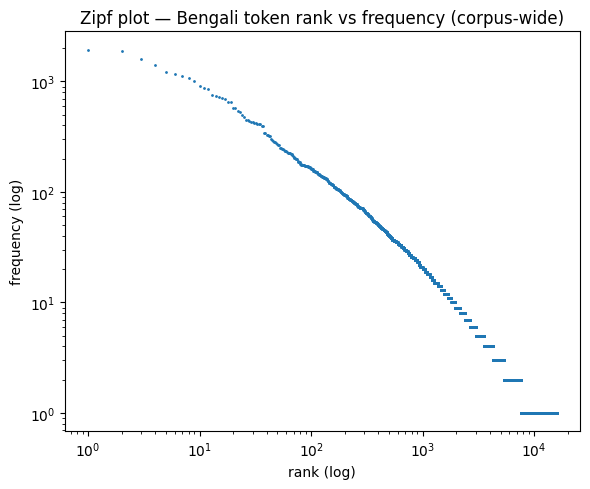

In [20]:
# Zipf-style rank-frequency plot -- a quick sanity check that the corpus behaves like
# natural-language text (relevant since it feeds a retrieval/embedding index later)
freqs = np.array(sorted(vocab_counter.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(ranks, freqs, marker=".", linestyle="none", markersize=2)
ax.set_xlabel("rank (log)")
ax.set_ylabel("frequency (log)")
ax.set_title("Zipf plot — Bengali token rank vs frequency (corpus-wide)")
plt.tight_layout()
plt.show()

## 4. Scan-quality metrics (on the actual split page images)

Same metric set as the original pass (blur, contrast, skew, connected-component stroke
integrity, large-blob area) but now computed directly on `data/pages/*.png` — i.e. the
images the pipeline will actually consume — rather than a freshly re-rendered copy.

In [21]:
def compute_accurate_skew(binary):
    edges = cv2.Canny(binary, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)
    if lines is None or len(lines) == 0:
        return 0.0
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if -15 < angle < 15:
            angles.append(angle)
    return float(np.median(angles)) if angles else 0.0

def measure_page(img_path):
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    color = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    h, w = gray.shape

    aspect_ratio = round(h / w, 3)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    mean_brightness = gray.mean()
    contrast_std = gray.std()

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    dark_pixel_ratio = (binary > 0).sum() / (h * w)

    m = int(0.05 * min(h, w))
    border_mask = np.ones_like(binary, dtype=bool)
    border_mask[m:h - m, m:w - m] = False
    border_dark_ratio = binary[border_mask].mean() / 255 if border_mask.any() else 0.0

    skew_angle_deg = compute_accurate_skew(binary)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if n_labels > 1:
        heights = stats[1:, cv2.CC_STAT_HEIGHT]
        areas = stats[1:, cv2.CC_STAT_AREA]
        glyph_min, glyph_max = 0.008 * h, 0.05 * h
        text_component_ratio = np.mean((heights >= glyph_min) & (heights <= glyph_max))
        large_blob_area_ratio = areas[areas > 0.05 * h * w].sum() / (h * w) if (areas > 0.05 * h * w).any() else 0.0
    else:
        text_component_ratio, large_blob_area_ratio = 0.0, 0.0

    channel_std = color.reshape(-1, 3).std(axis=0).mean()

    return {
        "width": w, "height": h, "aspect_ratio": aspect_ratio,
        "blur_score": round(blur_score, 1),
        "mean_brightness": round(mean_brightness, 1),
        "contrast_std": round(contrast_std, 1),
        "dark_pixel_ratio": round(dark_pixel_ratio, 4),
        "border_dark_ratio": round(border_dark_ratio, 4),
        "skew_angle_deg": round(skew_angle_deg, 2),
        "text_component_ratio": round(text_component_ratio, 3),
        "large_blob_area_ratio": round(large_blob_area_ratio, 3),
        "channel_std": round(channel_std, 2),
    }

quality_records = []
for _, row in tqdm(content_df.iterrows(), total=len(content_df), desc="Measuring scan quality"):
    q = measure_page(row.img_path)
    q.update({"book": row.book, "page_num": row.page_num, "page_id": row.page_id})
    quality_records.append(q)

quality_df = pd.DataFrame(quality_records)
print("=== Per-book mean scan-quality metrics ===")
metrics = ["blur_score", "mean_brightness", "contrast_std", "dark_pixel_ratio",
           "skew_angle_deg", "text_component_ratio", "large_blob_area_ratio"]
print(quality_df.groupby("book")[metrics].mean().round(2).to_string())

Measuring scan quality: 100%|██████████| 749/749 [00:55<00:00, 13.40it/s]


=== Per-book mean scan-quality metrics ===
                                     blur_score  mean_brightness  contrast_std  dark_pixel_ratio  skew_angle_deg  text_component_ratio  large_blob_area_ratio
book                                                                                                                                                         
Bharater-Krishi-Babyasthar-Parichay     3454.72           230.42         68.73              0.10           -0.03                  0.75                   0.03
Krishi-Bigyan                           7354.35           234.61         62.56              0.09            0.03                  0.82                   0.00
Krishi-Darpan                           9086.48           239.00         53.60              0.07           -0.04                  0.64                   0.00


/var/folders/fp/0cnl_tq17d7bnk4p55gcqxyw0000gn/T/ipykernel_83138/1244134656.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[b.split("-")[0] for b in BOOKS])
/var/folders/fp/0cnl_tq17d7bnk4p55gcqxyw0000gn/T/ipykernel_83138/1244134656.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[b.split("-")[0] for b in BOOKS])
/var/folders/fp/0cnl_tq17d7bnk4p55gcqxyw0000gn/T/ipykernel_83138/1244134656.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[b.split("-")[0] for b in BOOKS])
/var/folders/fp/0cnl_tq17d7bnk4p55gcqxyw0000gn/T/ipykernel_83138/12

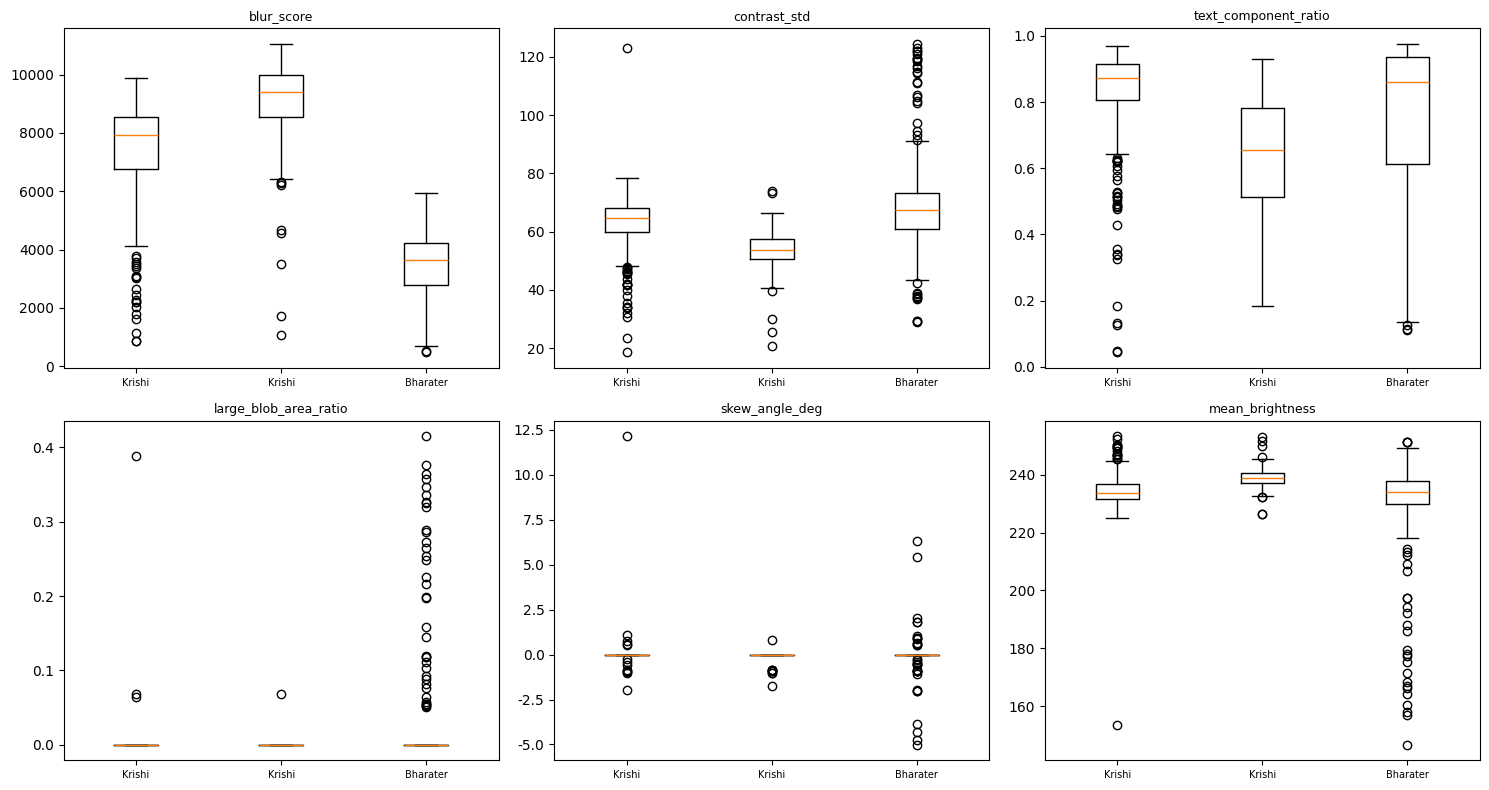

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_metrics = ["blur_score", "contrast_std", "text_component_ratio",
                 "large_blob_area_ratio", "skew_angle_deg", "mean_brightness"]
for ax, metric in zip(axes.flat, plot_metrics):
    data = [quality_df.loc[quality_df.book == b, metric].values for b in BOOKS]
    ax.boxplot(data, labels=[b.split("-")[0] for b in BOOKS])
    ax.set_title(metric, fontsize=9)
    ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

In [23]:
# Merge quality metrics with GT word counts to see whether degraded pages also transcribe shorter
merged = quality_df.merge(content_df[["page_id", "gt_word_count"]], on="page_id")
corr = merged[metrics + ["gt_word_count"]].corr(numeric_only=True)["gt_word_count"].drop("gt_word_count")
print("Correlation of scan-quality metrics with GT word count (proxy for extractable content):")
print(corr.round(3).to_string())

# Worst-quality pages per book -- useful as concrete examples in the A1 form / for the
# preprocessing sweep sample later
worst = (
    quality_df.assign(quality_rank=lambda d: d.groupby("book")["text_component_ratio"].rank())
    .sort_values(["book", "text_component_ratio"])
    .groupby("book")
    .head(3)[["page_id", "blur_score", "contrast_std", "text_component_ratio", "large_blob_area_ratio"]]
)
print("\nWorst 3 pages per book by text_component_ratio (candidates for preprocessing sweep):")
print(worst.to_string(index=False))

Correlation of scan-quality metrics with GT word count (proxy for extractable content):
blur_score               0.435
mean_brightness          0.142
contrast_std             0.010
dark_pixel_ratio        -0.125
skew_angle_deg          -0.023
text_component_ratio     0.599
large_blob_area_ratio   -0.426

Worst 3 pages per book by text_component_ratio (candidates for preprocessing sweep):
                                 page_id  blur_score  contrast_std  text_component_ratio  large_blob_area_ratio
Bharater-Krishi-Babyasthar-Parichay_p172      3623.8          63.3                 0.113                  0.000
Bharater-Krishi-Babyasthar-Parichay_p088      3115.5          69.1                 0.114                  0.000
Bharater-Krishi-Babyasthar-Parichay_p209      3225.8          91.6                 0.126                  0.120
                      Krishi-Bigyan_p221      4305.6          77.5                 0.044                  0.069
                      Krishi-Bigyan_p223      528

## 5. Train / val / test split, and the leakage check

Split is **by document**, never by page — Krishi-Bigyan + Bharater-Krishi-Babyasthar-Parichay
form train/val (582 pages / 75%), Krishi-Darpan is held out entirely as test (194 pages / 25%).

In [24]:
split_df = content_df.copy()
split_df["split"] = split_df.book.map(lambda b: "test" if b in TEST_BOOKS else "train_val")

split_counts = split_df.groupby("split").agg(pages=("page_num", "count"), books=("book", "unique"))
print(split_counts.to_string())
print(f"\ntrain_val: {split_counts.loc['train_val', 'pages']} pages "
      f"({100 * split_counts.loc['train_val', 'pages'] / len(split_df):.1f}%)")
print(f"test:      {split_counts.loc['test', 'pages']} pages "
      f"({100 * split_counts.loc['test', 'pages'] / len(split_df):.1f}%)")

# --- Leakage checks ---
train_val_books = set(split_df.loc[split_df.split == "train_val", "book"])
test_books = set(split_df.loc[split_df.split == "test", "book"])
assert train_val_books.isdisjoint(test_books), "LEAK: a book appears in both splits!"
print(f"\nBook-level overlap (train_val ∩ test): {train_val_books & test_books}  -> {'OK, empty' if not (train_val_books & test_books) else 'LEAK!'}")

train_val_ids = set(split_df.loc[split_df.split == "train_val", "page_id"])
test_ids = set(split_df.loc[split_df.split == "test", "page_id"])
assert train_val_ids.isdisjoint(test_ids), "LEAK: a page_id appears in both splits!"
print(f"Page-level overlap (train_val ∩ test): {len(train_val_ids & test_ids)} pages -> "
      f"{'OK, zero overlap' if not (train_val_ids & test_ids) else 'LEAK!'}")

           pages                                                 books
split                                                                 
test         188                                       [Krishi-Darpan]
train_val    561  [Bharater-Krishi-Babyasthar-Parichay, Krishi-Bigyan]

train_val: 561 pages (74.9%)
test:      188 pages (25.1%)

Book-level overlap (train_val ∩ test): set()  -> OK, empty
Page-level overlap (train_val ∩ test): 0 pages -> OK, zero overlap


## 6. Three example pages (image + Gemini ground truth)

Same three representative pages used in the A1 form (Section 3), now shown against the
verified Gemini transcription instead of a raw Tesseract guess.

=== Bharater-Krishi-Babyasthar-Parichay — page 141 (page_id=Bharater-Krishi-Babyasthar-Parichay_p141) ===
Image size: (1275, 1650)  |  GT word count: 149

--- Ground-truth excerpt ---
১১২         **ভারতের কৃষি-ব্যবস্থার পরিচয়**

| মৌল | | মৌল | প্রতীক |
| :--- | :--- | :--- | :--- |
| কার্বন (carbon) | (C) | ম্যাগনেশিয়াম (magnesium) | (Mg) |
| হাইড্রোজেন (Hydrogen) | (H) | আইরণ (iron) | (Fe) |
| অক্সিজেন (Oxygen) | (O) | ম্যাঙ্গানিজ (manganese) | (Mn) |
| নাইট্রোজেন (nitrogen) | (N) | জিংক (zinc) | (Zn) |
| ফসফরাস (phosphorus) | (P) | কপার (copper) | (Cu) |
| সালফার (sulphur) | (S) | মলিবডেনম (molybdenum) | (Mo) |
| পটাশিয়াম (potassium) | (K) | বোরন (boron) | (B) |
| ক্যালশিয়াম (Calcium) | (Ca) | ক্লোরিন (chlorine) | (Cl) |


<figure>
চিত্র নং ৫৩। শিম্বীগোত্রীয় উদ্ভিদের মূলে অর্বুদ (nodule)। ইহাদের ভিতরে, একপ্রকার ব্যাকটিরিয়া বায়ুমণ্ডল হইতে নাইট্রোজেন বন্ধন করিয়া মাটির উর্বরতা বাড়ায়। চিত্রে লুসার্ন (lucerne) উদ্ভিদের মূল দেখানো হইয়াছে। ১. শাখা মূল, ২. অর্বুদ,...


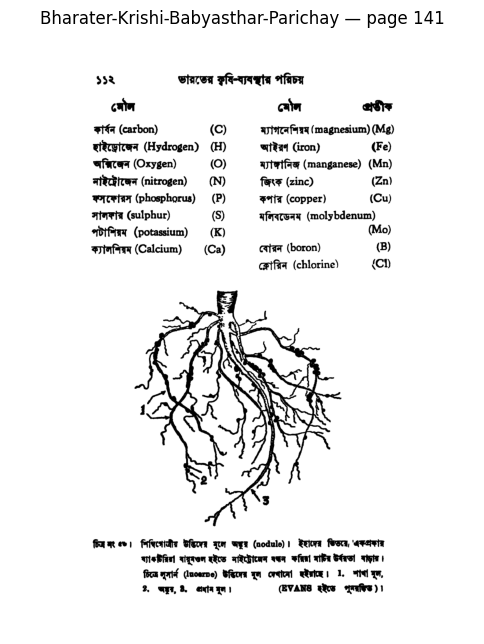

In [25]:
def show_example(book, page_num, gt_chars=800):
    img_path = page_img_path_for(book, page_num)
    gtp = gt_path_for(book, page_num)
    assert img_path.exists(), f"Missing image: {img_path}"

    gt_text = gtp.read_text(encoding="utf-8") if gtp.exists() else "(no ground truth found)"
    img = Image.open(img_path)

    print(f"=== {book} — page {page_num} (page_id={book}_p{page_num:03d}) ===")
    print(f"Image size: {img.size}  |  GT word count: {len(gt_text.split())}\n")
    print("--- Ground-truth excerpt ---")
    print(gt_text[:gt_chars] + ("..." if len(gt_text) > gt_chars else ""))

    plt.figure(figsize=(6, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{book} — page {page_num}")
    plt.show()
    return gt_text

_ = show_example("Bharater-Krishi-Babyasthar-Parichay", 141)

=== Krishi-Darpan — page 9 (page_id=Krishi-Darpan_p009) ===
Image size: (569, 913)  |  GT word count: 187

--- Ground-truth excerpt ---
২           উপক্রমণিকা।

সংযোগে অবশ্য বিশেষ হানি হইতে পারে, তৎপ্রযুক্ত তদ্-
উপযুক্ত আহারীয় দ্রব্য যে স্নিগ্ধসামগ্রী অর্থাৎ ফল মূল
অন্যান্য উদ্ভিজ্জ ইহাই সর্ব্বতোভাবে এদেশীয় জীবের
ভোজনার্হ ; অতএব এই কারণবশতঃ বঙ্গদেশ নিবাসি
লোকেরা কৃষিকার্য্য করিয়া থাকেন কিন্তু কৃষিবিদ্যার কি-
ছুই আলোচনা নাই, অর্থাৎ যাহাতে কার্য্যের কারণ
প্রকাশ পাইতে পারে এমত কোন উপায় অবধারিত নাই।
যদিও চারা উৎপত্তি করিবার কারণ মৃত্তিকা খনন, সার
দেওয়া, অকর্ম্মণ্য তৃণদিগকে নষ্ট করা, সময়ে২ শাখাক্ছেদ
ও জলসেচন করা, এবং ইহাকে রোগ হইতে মুক্ত করা
ইত্যাদি ক্রিয়া কলাপ যাহা কৃষিকার্য্যের অঙ্গুল হইয়াছে
তাহার বিষয় কিঞ্চিৎ কিঞ্চিৎ অনেকে অবগত আছেন, কিন্তু
এই সকল ক্রিয়ার দ্বারা উদ্ভিজ্জদিগের জীবনোপযোগি
ক্রিয়া সকল কিরূপে নির্ব্বাহ হইতেছে, তাহা কেহই জ্ঞাত
নহেন। অতএব এই সকল বিষয় প্রকাশ করিবার মানসে
আমরা প্রথমতঃ দেখিলাম যে ঐ সকল অনু...


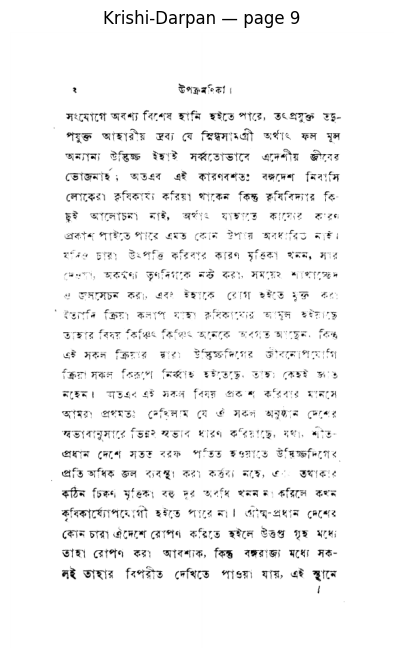

In [26]:
_ = show_example("Krishi-Darpan", 9)

=== Krishi-Bigyan — page 106 (page_id=Krishi-Bigyan_p106) ===
Image size: (748, 1173)  |  GT word count: 236

--- Ground-truth excerpt ---
উদ্ভিদের প্রাণতত্ত্ব  ৮৭

প্রাণিগণের ভুক্ত দ্রব্য পাকস্থলী এবং পাকাশয়ে পরিপক্ক হইয়া উহার সারাংশ দ্রব অবস্থায় সমস্ত শরীরে পরিচালিত হয় এবং তদ্দ্বারা রক্ত, মাংস, অস্থি প্রভৃতি দৈহিক উপাদান গঠিত হইয়া থাকে। প্রাণিগণের আহারের সময়ে আহার্য্য সামগ্রী লালার সহিত মিশ্রিত হইয়া, কণ্ঠনালী-দ্বারা পাকস্থলীতে প্রবেশ করে। লালার মধ্যে "শ্বেতসার কিণ্্ব" (diastase) নামে এক প্রকার অজৈব অন্তরুৎসেক (enzyme) আছে। ঐ অজৈব অন্তরুৎসেক শ্বেতসারের উপর ক্রিয়া করিয়া উহাকে শর্করাতে (sugar) পরিণত করে। "শ্বেতসার কিণ্্ব"র (diastase) ক্রিয়া আহারের সময়ে মুখের মধ্যে আরম্ভ হইয়া পাকাশয়ে যাইয়া সমাপ্ত হয়। উক্ত শর্করাদ্বারা প্রাণীর দেহ পুষ্ট হইয়া থাকে। পাকস্থলী হইতেও এক প্রকার পাচক রস নির্গত হইয়া ভুক্ত দ্রব্যের সহিত মিশ্রিত হয়। ঐ রসের মধ্যে 'পেপ্সিন' (pepsin) নামক এক প্রকার অজৈব অন্তরুৎসেক (enzyme) বর্তমান থাকে। ঐ অজৈব অন্তরুৎসেক অন্...


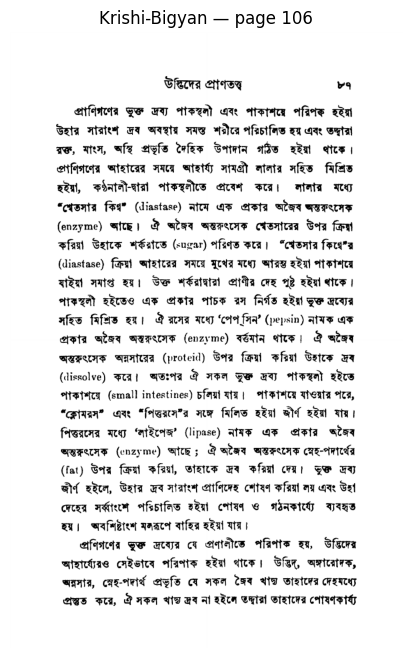

In [27]:
_ = show_example("Krishi-Bigyan", 106)

## 7. OCR tool bake-off

We now have real ground truth, so instead of guessing which OCR engine will handle Bangla
conjuncts/matras well, we measure it. We compare:

- **Tesseract** (`lang="ben"`) — the incumbent baseline from the earlier pass.
- **EasyOCR** (`lang_list=["bn"]`) — CRNN-based, GPU-accelerated.
- **PaddleOCR** (`lang="bn"` via the multilingual PP-OCR models).
- **Surya OCR** — modern multilingual OCR with strong reported Bengali/Indic performance,
  included as a candidate for degraded historical scans.

Each tool runs on the **same stratified sample** of pages (drawn across all three books,
weighted toward the worst-quality pages found in Section 4, since that's where tool choice
matters most) and is scored against the Gemini GT with **CER** and **WER** via `jiwer`.

> Run the pip installs below once per environment (Kaggle/local). Skip cells for tools you
> don't have access to — the comparison degrades gracefully to whichever subset is installed.

In [28]:
# One-time installs (uncomment as needed). On Kaggle, prefer the dual-T4 GPU runtime for
# EasyOCR / Surya, which are far slower on CPU.
# !pip install -q jiwer easyocr paddleocr paddlepaddle-gpu surya-ocr pytesseract

In [39]:
import jiwer
import pytesseract

TOOLS_AVAILABLE = {}

try:
    import pytesseract as _pt
    TOOLS_AVAILABLE["tesseract"] = True
except ImportError:
    TOOLS_AVAILABLE["tesseract"] = False

try:
    import easyocr
    TOOLS_AVAILABLE["easyocr"] = True
except ImportError:
    TOOLS_AVAILABLE["easyocr"] = False

try:
    from paddleocr import PaddleOCR
    # Bengali support depends on the installed version -- 3.x dropped the explicit "bn"
    # language code (consolidated into script families that don't cover Bengali). Probe
    # this at import time rather than letting every downstream call crash on the same
    # AssertionError.
    try:
        PaddleOCR(lang="bn")
        TOOLS_AVAILABLE["paddleocr"] = True
    except AssertionError:
        print("[paddleocr] installed, but this version doesn't support lang='bn' "
              "(likely PaddleOCR>=3.0, which dropped Bengali). Skipping this tool. "
              "Downgrade to paddleocr<3.0 if you need it in the bake-off.")
        TOOLS_AVAILABLE["paddleocr"] = False
except ImportError:
    TOOLS_AVAILABLE["paddleocr"] = False

try:
    from surya.recognition import RecognitionPredictor
    from surya.detection import DetectionPredictor
    TOOLS_AVAILABLE["surya"] = True
except ImportError:
    TOOLS_AVAILABLE["surya"] = False

print("OCR tools available in this environment:")
for k, v in TOOLS_AVAILABLE.items():
    print(f"  {k:12s} {'YES' if v else 'no (skipped below)'}")

[paddleocr] installed, but this version doesn't support lang='bn' (likely PaddleOCR>=3.0, which dropped Bengali). Skipping this tool. Downgrade to paddleocr<3.0 if you need it in the bake-off.
OCR tools available in this environment:
  tesseract    YES
  easyocr      YES
  paddleocr    no (skipped below)
  surya        no (skipped below)


In [40]:
# --- Lazy-init each engine only if available, so the notebook still runs top-to-bottom
# without every tool installed. ---

_easyocr_reader = None
def get_easyocr_reader():
    global _easyocr_reader
    if _easyocr_reader is None:
        _easyocr_reader = easyocr.Reader(["bn"], gpu=True)
    return _easyocr_reader

_paddle_reader = None
def get_paddle_reader():
    global _paddle_reader
    if _paddle_reader is None:
        _paddle_reader = PaddleOCR(use_angle_cls=True, lang="bn", show_log=False)
    return _paddle_reader

_surya_rec = None
_surya_det = None
def get_surya():
    global _surya_rec, _surya_det
    if _surya_rec is None:
        _surya_rec = RecognitionPredictor()
        _surya_det = DetectionPredictor()
    return _surya_rec, _surya_det


def ocr_tesseract(pil_img):
    return pytesseract.image_to_string(pil_img, lang="ben")

def ocr_easyocr(pil_img):
    reader = get_easyocr_reader()
    result = reader.readtext(np.array(pil_img), detail=0, paragraph=True)
    return "\n".join(result)

def ocr_paddleocr(pil_img):
    """PaddleOCR's return shape changed between 2.x (nested list: [[[box, (text, score)], ...]])
    and 3.x (list of result objects with .rec_texts / ["rec_texts"]). Handle both rather than
    assuming one -- a shape mismatch here is the most common reason this tool comes back
    all-NaN in the bake-off (silent exception, not a real OCR failure)."""
    reader = get_paddle_reader()
    img_arr = np.array(pil_img)

    # Try the modern .predict() interface first (PaddleOCR >=3.0)
    if hasattr(reader, "predict"):
        result = reader.predict(img_arr)
        lines = []
        for res in (result or []):
            texts = res.get("rec_texts") if isinstance(res, dict) else getattr(res, "rec_texts", None)
            if texts:
                lines.extend(texts)
        if lines:
            return "\n".join(lines)

    # Fall back to the legacy .ocr() interface (PaddleOCR 2.x)
    result = reader.ocr(img_arr, cls=True)
    lines = []
    for block in (result or []):
        for line in (block or []):
            # line == [box, (text, score)]
            lines.append(line[1][0])
    return "\n".join(lines)

def ocr_surya(pil_img):
    rec, det = get_surya()
    predictions = rec([pil_img], det_predictor=det)
    return "\n".join(line.text for line in predictions[0].text_lines)

OCR_FUNCS = {
    "tesseract": ocr_tesseract,
    "easyocr": ocr_easyocr,
    "paddleocr": ocr_paddleocr,
    "surya": ocr_surya,
}

In [41]:
# --- Build the evaluation sample: stratified across books, biased toward low
# text_component_ratio pages (our known hardest cases from Section 4). ---

N_PER_BOOK = 12  # keep this small-ish; OCR bake-off is expensive across 4 tools

eval_rows = []
for book in BOOKS:
    book_quality = quality_df[quality_df.book == book].merge(
        content_df[["page_id", "gt_word_count"]], on="page_id"
    )
    book_quality = book_quality[book_quality.gt_word_count > 20]  # skip near-empty pages
    hard_half = book_quality.nsmallest(N_PER_BOOK // 2, "text_component_ratio")
    random_half = book_quality.drop(hard_half.index).sample(
        n=min(N_PER_BOOK - len(hard_half), len(book_quality) - len(hard_half)),
        random_state=42,
    )
    eval_rows.append(pd.concat([hard_half, random_half]))

eval_sample = pd.concat(eval_rows).reset_index(drop=True)
print(f"OCR bake-off sample: {len(eval_sample)} pages across {eval_sample.book.nunique()} books")
eval_sample[["page_id", "book", "text_component_ratio", "gt_word_count"]]

OCR bake-off sample: 36 pages across 3 books


,page_id,book,text_component_ratio,gt_word_count
0,Krishi-Bigyan_p005,Krishi-Bigyan,0.133,31
1,Krishi-Bigyan_p247,Krishi-Bigyan,0.185,69
2,Krishi-Bigyan_p203,Krishi-Bigyan,0.326,198
3,Krishi-Bigyan_p201,Krishi-Bigyan,0.338,243
4,Krishi-Bigyan_p157,Krishi-Bigyan,0.341,64
5,Krishi-Bigyan_p202,Krishi-Bigyan,0.356,197
6,Krishi-Bigyan_p014,Krishi-Bigyan,0.855,180
7,Krishi-Bigyan_p265,Krishi-Bigyan,0.797,261
8,Krishi-Bigyan_p167,Krishi-Bigyan,0.725,186
9,Krishi-Bigyan_p224,Krishi-Bigyan,0.620,163


In [42]:
# --- Diagnostic: run each available tool ONCE on a single page, with the exception
# surfaced in full, before the big loop. The bake-off's try/except silently turns any
# failure into NaN, which is exactly why "all NaN for one tool" gives no clue on its own --
# this cell is where you find out *why*, instead of guessing.
import traceback

_diag_img = Image.open(page_img_path_for(eval_sample.iloc[0].book, eval_sample.iloc[0].page_num))

for tool_name, ocr_fn in OCR_FUNCS.items():
    if not TOOLS_AVAILABLE.get(tool_name):
        print(f"[{tool_name}] not installed, skipped")
        continue
    try:
        out = ocr_fn(_diag_img)
        print(f"[{tool_name}] OK -- {len(out)} chars, e.g. {out[:60]!r}")
    except Exception:
        print(f"[{tool_name}] FAILED -- full traceback below:")
        traceback.print_exc()
    print("-" * 60)

[tesseract] OK -- 204 chars, e.g. '৯ম সংরণ-7ম15, 1099--\n২য় », 0০৩, 1য়\n\nসযাসপশতাও বায হস্বা)া/'
------------------------------------------------------------
[easyocr] OK -- 242 chars, e.g. '১ম সংসরণ-স1ণড়, 1928 -ঢ ২থ  $"১ঙ, 198} !\nফং$৩শভ০\n13ঝ]^\n1\'31"\''
------------------------------------------------------------
[paddleocr] not installed, skipped
[surya] not installed, skipped


In [43]:
def normalize_for_scoring(text):
    """NFC-normalize, strip Markdown structure, and collapse whitespace so CER/WER isn't
    inflated by formatting noise. Gemini GT frequently comes back with light Markdown
    (headings, bullets, bold, table pipes) that no OCR engine ever emits -- every one of
    those stray symbols is a free edit-distance penalty against the hypothesis, so they
    must be stripped from BOTH ref and hyp before scoring, not just whitespace-collapsed."""
    text = unicodedata.normalize("NFC", text)

    # Fenced code blocks -> drop entirely (Gemini sometimes wraps tables/lists in ``` )
    text = re.sub(r"```.*?```", " ", text, flags=re.DOTALL)
    # Inline code spans -> keep content, drop backticks
    text = re.sub(r"`([^`]*)`", r"\1", text)
    # ATX headings: leading #'s
    text = re.sub(r"(?m)^\s{0,3}#{1,6}\s*", "", text)
    # Bold / italic / strikethrough markers (Bengali script never uses these ASCII symbols)
    text = re.sub(r"\*\*\*|\*\*|\*|__|~~", "", text)
    # Bullet list markers at line start (-, *, +, • )
    text = re.sub(r"(?m)^\s*[-*+•]\s+", "", text)
    # Numbered list markers at line start ("1. ", "12) ")
    text = re.sub(r"(?m)^\s*\d+[.)]\s+", "", text)
    # Blockquote markers
    text = re.sub(r"(?m)^\s*>\s?", "", text)
    # Horizontal rules ( ---, ***, === on their own line )
    text = re.sub(r"(?m)^\s*([-*=_])\1{2,}\s*$", "", text)
    # Table pipes -> space (keep cell content, drop the delimiter itself)
    text = text.replace("|", " ")
    # Markdown links / images: [text](url) or ![alt](url) -> keep just the text
    text = re.sub(r"!?\[([^\]]*)\]\([^)]*\)", r"\1", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

bakeoff_records = []
_printed_error_for = set()  # print only the FIRST failure per tool -- avoids flooding
                             # the log with one traceback per page while still surfacing
                             # the actual cause instead of a silent all-NaN column.

for _, row in tqdm(eval_sample.iterrows(), total=len(eval_sample), desc="OCR bake-off"):
    img_path = page_img_path_for(row.book, row.page_num)
    gtp = gt_path_for(row.book, row.page_num)
    if not (img_path.exists() and gtp.exists()):
        continue
    pil_img = Image.open(img_path)
    ref = normalize_for_scoring(gtp.read_text(encoding="utf-8"))
    if not ref:
        continue

    for tool_name, ocr_fn in OCR_FUNCS.items():
        if not TOOLS_AVAILABLE.get(tool_name):
            continue
        try:
            hyp = normalize_for_scoring(ocr_fn(pil_img))
            cer = jiwer.cer(ref, hyp) if hyp else 1.0
            wer = jiwer.wer(ref, hyp) if hyp else 1.0
        except Exception as e:
            cer, wer, hyp = np.nan, np.nan, f"[ERROR: {e}]"
            if tool_name not in _printed_error_for:
                print(f"\n[{tool_name}] first failure on {row.page_id}: {e!r}")
                _printed_error_for.add(tool_name)
        bakeoff_records.append({
            "page_id": row.page_id, "book": row.book, "tool": tool_name,
            "cer": cer, "wer": wer, "hyp_len": len(hyp) if isinstance(hyp, str) else 0,
        })

bakeoff_df = pd.DataFrame(bakeoff_records)
if not bakeoff_df.empty:
    fail_rate = bakeoff_df.groupby("tool")["cer"].apply(lambda s: s.isna().mean())
    fully_failed = fail_rate[fail_rate == 1.0]
    if not fully_failed.empty:
        print(f"\nTool(s) that failed on EVERY page (all-NaN): {list(fully_failed.index)}")
        print("See the diagnostic cell above for the actual exception, or re-run it after fixing.")

OCR bake-off: 100%|██████████| 36/36 [03:14<00:00,  5.40s/it]


=== Mean CER / WER by tool (lower is better) ===
              cer     wer
tool                     
tesseract  0.4109  0.6551
easyocr    0.4946  0.8997

=== Mean CER / WER by tool x book ===
                                                  cer     wer
tool      book                                               
easyocr   Bharater-Krishi-Babyasthar-Parichay  0.6596  1.0546
          Krishi-Bigyan                        0.5167  0.8335
          Krishi-Darpan                        0.3075  0.8110
tesseract Bharater-Krishi-Babyasthar-Parichay  0.5030  0.7428
          Krishi-Bigyan                        0.4480  0.6960
          Krishi-Darpan                        0.2817  0.5266


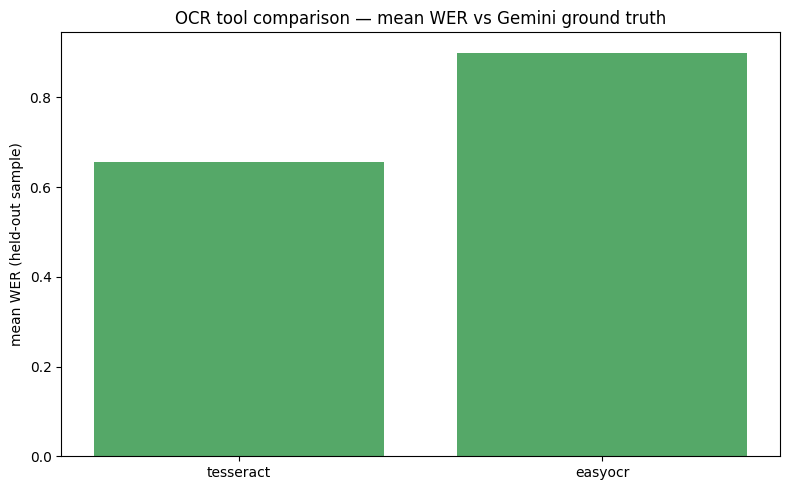


Best-performing OCR tool on this sample: tesseract


In [44]:
if bakeoff_df.empty:
    print("No OCR tools were available in this environment -- install at least one "
          "(tesseract/easyocr/paddleocr/surya) and re-run Section 7.")
else:
    print("=== Mean CER / WER by tool (lower is better) ===")
    print(bakeoff_df.groupby("tool")[["cer", "wer"]].mean().round(4).sort_values("wer").to_string())

    print("\n=== Mean CER / WER by tool x book ===")
    print(bakeoff_df.groupby(["tool", "book"])[["cer", "wer"]].mean().round(4).to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    pivot = bakeoff_df.groupby("tool")["wer"].mean().sort_values()
    ax.bar(pivot.index, pivot.values, color="#55A868")
    ax.set_ylabel("mean WER (held-out sample)")
    ax.set_title("OCR tool comparison — mean WER vs Gemini ground truth")
    plt.tight_layout()
    plt.show()

    BEST_TOOL = pivot.idxmin()
    print(f"\nBest-performing OCR tool on this sample: {BEST_TOOL}")

## 8. Preprocessing sweep on the winning OCR tool

Now we test the preprocessing operations named in the A1 form (Section 2 / Section 5) —
individually and combined — using **`BEST_TOOL`** from Section 7, on the same evaluation
sample. This tells us, per book, which recipe actually reduces CER/WER rather than
assuming it does.

In [45]:
def to_cv(pil_img):
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def to_pil(cv_img):
    if cv_img.ndim == 2:
        return Image.fromarray(cv_img)
    return Image.fromarray(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))

def prep_none(pil_img):
    return pil_img

def prep_deskew(pil_img):
    cv_img = to_cv(pil_img)
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    angle = compute_accurate_skew(binary)
    if abs(angle) < 0.1:
        return pil_img
    h, w = gray.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(cv_img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return to_pil(rotated)

def prep_denoise(pil_img):
    cv_img = to_cv(pil_img)
    blurred = cv2.GaussianBlur(cv_img, (3, 3), 0)
    return to_pil(blurred)

def prep_clahe_otsu(pil_img):
    gray = cv2.cvtColor(to_cv(pil_img), cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return to_pil(binary)

def prep_margin_crop(pil_img, margin_px=100):
    cv_img = to_cv(pil_img)
    h, w = cv_img.shape[:2]
    m = min(margin_px, h // 4, w // 4)
    return to_pil(cv_img[m:h - m, m:w - m])

def prep_stroke_repair(pil_img):
    gray = cv2.cvtColor(to_cv(pil_img), cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return to_pil(255 - closed)  # back to black-text-on-white for OCR

def prep_unsharp(pil_img, radius=1.5, strength=0.8):
    cv_img = to_cv(pil_img)
    blurred = cv2.GaussianBlur(cv_img, (0, 0), radius)
    sharpened = cv2.addWeighted(cv_img, 1 + strength, blurred, -strength, 0)
    return to_pil(sharpened)

def prep_full_recipe(pil_img, book):
    '''Per-book targeted recipe, matching what's proposed in the A1 form.'''
    img = pil_img
    if book == "Bharater-Krishi-Babyasthar-Parichay":
        img = prep_denoise(img)
        img = prep_clahe_otsu(img)
    elif book == "Krishi-Bigyan":
        img = prep_clahe_otsu(img)
        img = prep_unsharp(img)
    elif book == "Krishi-Darpan":
        img = prep_stroke_repair(img)
        img = prep_unsharp(img)
    img = prep_margin_crop(img)
    return img

PREP_FUNCS = {
    "raw": prep_none,
    "deskew": prep_deskew,
    "denoise": prep_denoise,
    "clahe_otsu": prep_clahe_otsu,
    "margin_crop": prep_margin_crop,
    "stroke_repair": prep_stroke_repair,
    "unsharp": prep_unsharp,
    "per_book_recipe": None,  # handled specially below (needs book name)
}

In [46]:
best_ocr_fn = OCR_FUNCS[BEST_TOOL]

sweep_records = []
for _, row in tqdm(eval_sample.iterrows(), total=len(eval_sample), desc=f"Preprocessing sweep ({BEST_TOOL})"):
    img_path = page_img_path_for(row.book, row.page_num)
    gtp = gt_path_for(row.book, row.page_num)
    if not (img_path.exists() and gtp.exists()):
        continue
    pil_img = Image.open(img_path)
    ref = normalize_for_scoring(gtp.read_text(encoding="utf-8"))
    if not ref:
        continue

    for prep_name, prep_fn in PREP_FUNCS.items():
        try:
            variant_img = (prep_full_recipe(pil_img, row.book) if prep_name == "per_book_recipe"
                           else prep_fn(pil_img))
            hyp = normalize_for_scoring(best_ocr_fn(variant_img))
            cer = jiwer.cer(ref, hyp) if hyp else 1.0
            wer = jiwer.wer(ref, hyp) if hyp else 1.0
        except Exception as e:
            cer, wer = np.nan, np.nan
        sweep_records.append({
            "page_id": row.page_id, "book": row.book, "prep": prep_name,
            "cer": cer, "wer": wer,
        })

sweep_df = pd.DataFrame(sweep_records)
sweep_df.to_csv("preprocessing_sweep_results.csv", index=False)
sweep_df.head()

Preprocessing sweep (tesseract): 100%|██████████| 36/36 [02:06<00:00,  3.52s/it]


,page_id,book,prep,cer,wer
0,Krishi-Bigyan_p005,Krishi-Bigyan,raw,0.755760,1.000000
1,Krishi-Bigyan_p005,Krishi-Bigyan,deskew,0.755760,1.000000
2,Krishi-Bigyan_p005,Krishi-Bigyan,denoise,0.769585,0.967742
3,Krishi-Bigyan_p005,Krishi-Bigyan,clahe_otsu,0.778802,0.967742
4,Krishi-Bigyan_p005,Krishi-Bigyan,margin_crop,0.728111,1.000000


In [47]:
print(f"=== Preprocessing sweep results using {BEST_TOOL} (mean CER / WER, lower is better) ===\n")
overall = sweep_df.groupby("prep")[["cer", "wer"]].mean().round(4).sort_values("wer")
print("--- Corpus-wide ---")
print(overall.to_string())

print("\n--- Per book ---")
per_book_sweep = sweep_df.groupby(["book", "prep"])[["cer", "wer"]].mean().round(4)
for book in BOOKS:
    print(f"\n{book}:")
    print(per_book_sweep.loc[book].sort_values("wer").to_string())

=== Preprocessing sweep results using tesseract (mean CER / WER, lower is better) ===

--- Corpus-wide ---
                    cer     wer
prep                           
denoise          0.3847  0.6367
deskew           0.4128  0.6547
raw              0.4109  0.6551
unsharp          0.4246  0.6729
clahe_otsu       0.4379  0.7063
margin_crop      0.4541  0.7336
stroke_repair    0.4822  0.8287
per_book_recipe  0.5027  0.8298

--- Per book ---

Krishi-Bigyan:
                    cer     wer
prep                           
denoise          0.4593  0.6622
deskew           0.4480  0.6960
raw              0.4480  0.6960
unsharp          0.4502  0.7129
clahe_otsu       0.4589  0.7206
margin_crop      0.4962  0.8035
per_book_recipe  0.5116  0.8201
stroke_repair    0.5262  0.8543

Krishi-Darpan:
                    cer     wer
prep                           
denoise          0.1867  0.4872
deskew           0.2816  0.5216
raw              0.2817  0.5266
unsharp          0.3134  0.5521
margin_crop

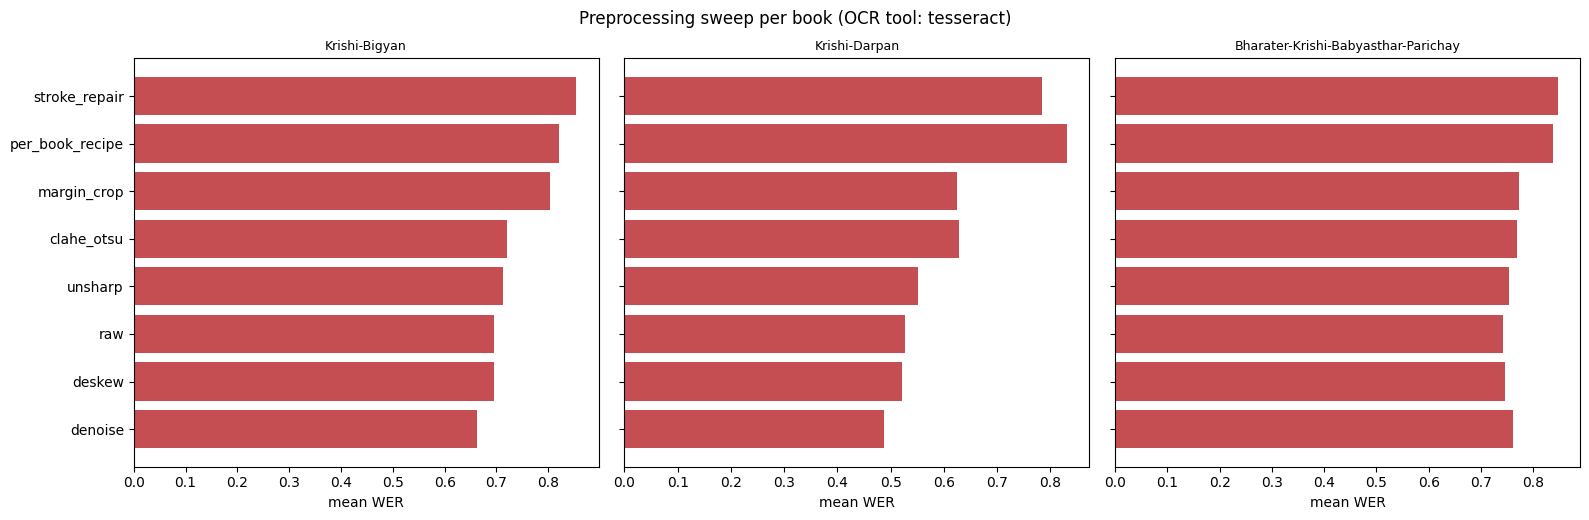

=== Best preprocessing recipe per book ===
                               book    prep      wer
Bharater-Krishi-Babyasthar-Parichay     raw 0.742797
                      Krishi-Bigyan denoise 0.662177
                      Krishi-Darpan denoise 0.487172


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, book in zip(axes, BOOKS):
    sub = sweep_df[sweep_df.book == book].groupby("prep")["wer"].mean().sort_values()
    ax.barh(sub.index, sub.values, color="#C44E52")
    ax.set_title(book, fontsize=9)
    ax.set_xlabel("mean WER")
plt.tight_layout()
plt.suptitle(f"Preprocessing sweep per book (OCR tool: {BEST_TOOL})", y=1.03)
plt.show()

best_per_book = sweep_df.groupby(["book", "prep"])["wer"].mean().reset_index()
best_per_book = best_per_book.loc[best_per_book.groupby("book")["wer"].idxmin()]
print("=== Best preprocessing recipe per book ===")
print(best_per_book.to_string(index=False))

In [2]:
import re
from pathlib import Path
import numpy as np

gt_root = Path("../data/ground-truth-ocr")

BENGALI_RANGE = (0x0980, 0x09FF)

def is_bengali_char(ch: str) -> bool:
    return BENGALI_RANGE[0] <= ord(ch) <= BENGALI_RANGE[1]

def is_latin_char(ch: str) -> bool:
    return ch.isascii() and ch.isalpha()

def char_counts(text: str) -> tuple[int, int, int]:
    """Returns (bengali_alpha_chars, latin_alpha_chars, total_alpha_chars)."""
    bengali = sum(1 for ch in text if is_bengali_char(ch))
    latin = sum(1 for ch in text if is_latin_char(ch))
    total_alpha = bengali + latin
    return bengali, latin, total_alpha

BRACKET_PATTERN = re.compile(r"[\(\[\{][^\)\]\}]*[\)\]\}]")

def english_in_brackets(text: str) -> tuple[int, int]:
    """Returns (latin_chars_inside_brackets, latin_chars_total) for a line."""
    total_latin = sum(1 for ch in text if is_latin_char(ch))
    bracket_latin = 0
    for match in BRACKET_PATTERN.finditer(text):
        span = match.group(0)
        bracket_latin += sum(1 for ch in span if is_latin_char(ch))
    return bracket_latin, total_latin


# ---------------------------------------------------------------------------
# Per-line stats across the whole GT corpus
# ---------------------------------------------------------------------------

line_records = []   # (doc_id, page_stem, line_idx, bengali, latin, total_alpha, latin_ratio)
total_bengali_chars = 0
total_latin_chars = 0
total_alpha_chars = 0
total_bracket_latin = 0
total_lines = 0
lines_with_any_english = 0

for doc_dir in sorted(gt_root.iterdir()):
    if not doc_dir.is_dir():
        continue
    doc_id = doc_dir.name
    for gt_file in sorted(doc_dir.glob("*.txt")):
        page_stem = gt_file.stem
        text = gt_file.read_text(encoding="utf-8")
        lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
        for i, line in enumerate(lines):
            bengali, latin, total_alpha = char_counts(line)
            bracket_latin, line_total_latin = english_in_brackets(line)

            total_bengali_chars += bengali
            total_latin_chars += latin
            total_alpha_chars += total_alpha
            total_bracket_latin += bracket_latin
            total_lines += 1
            if latin > 0:
                lines_with_any_english += 1

            latin_ratio = latin / total_alpha if total_alpha > 0 else 0.0
            line_records.append((doc_id, page_stem, i, bengali, latin, total_alpha, latin_ratio))

if total_lines == 0:
    print(f"No GT files found under {gt_root} -- check the path.")
else:
    latin_ratios = np.array([r[6] for r in line_records])
    lines_with_english_ratios = latin_ratios[latin_ratios > 0]

    print("=== Corpus-wide character composition ===")
    print(f"total lines                 : {total_lines}")
    print(f"total alphabetic chars      : {total_alpha_chars}")
    print(f"bengali chars               : {total_bengali_chars}  ({100*total_bengali_chars/total_alpha_chars:.2f}%)")
    print(f"latin (english) chars       : {total_latin_chars}  ({100*total_latin_chars/total_alpha_chars:.2f}%)")
    print()
    print(f"latin chars inside brackets : {total_bracket_latin}  "
          f"({100*total_bracket_latin/total_latin_chars:.2f}% of all latin chars)" if total_latin_chars else "n/a")
    print()
    print("=== Per-line english ratio (latin_chars / total_alpha_chars) ===")
    print(f"lines with ANY english char : {lines_with_english_ratios.size} / {total_lines} "
          f"({100*lines_with_english_ratios.size/total_lines:.2f}%)")
    if lines_with_english_ratios.size:
        print(f"  -- stats over lines containing english --")
        print(f"  min  : {lines_with_english_ratios.min():.4f}")
        print(f"  max  : {lines_with_english_ratios.max():.4f}")
        print(f"  mean : {lines_with_english_ratios.mean():.4f}")
        print(f"  median : {np.median(lines_with_english_ratios):.4f}")
    print()
    print(f"  -- stats over ALL lines (including pure-bengali, ratio=0) --")
    print(f"  min  : {latin_ratios.min():.4f}")
    print(f"  max  : {latin_ratios.max():.4f}")
    print(f"  mean : {latin_ratios.mean():.4f}")

    print()
    print("=== Per-book breakdown ===")
    by_book: dict[str, list[float]] = {}
    for doc_id, _p, _i, _b, latin, total_alpha, ratio in line_records:
        by_book.setdefault(doc_id, []).append(ratio)
    for doc_id, ratios in by_book.items():
        arr = np.array(ratios)
        eng_lines = arr[arr > 0]
        print(f"{doc_id}: {eng_lines.size}/{arr.size} lines have english "
              f"({100*eng_lines.size/arr.size:.1f}%), mean_ratio_when_present="
              f"{eng_lines.mean() if eng_lines.size else 0:.4f}")

    print()
    print("=== Top 15 lines by english ratio (spot-check these) ===")
    top = sorted(line_records, key=lambda r: r[6], reverse=True)[:15]
    for doc_id, page_stem, idx, bengali, latin, total_alpha, ratio in top:
        print(f"{doc_id}/{page_stem} line {idx}: ratio={ratio:.3f} (latin={latin}, bengali={bengali})")

=== Corpus-wide character composition ===
total lines                 : 17760
total alphabetic chars      : 703126
bengali chars               : 683783  (97.25%)
latin (english) chars       : 19343  (2.75%)

latin chars inside brackets : 14773  (76.37% of all latin chars)

=== Per-line english ratio (latin_chars / total_alpha_chars) ===
lines with ANY english char : 1687 / 17760 (9.50%)
  -- stats over lines containing english --
  min  : 0.0161
  max  : 1.0000
  mean : 0.3723
  median : 0.2857

  -- stats over ALL lines (including pure-bengali, ratio=0) --
  min  : 0.0000
  max  : 1.0000
  mean : 0.0354

=== Per-book breakdown ===
Bharater-Krishi-Babyasthar-Parichay: 933/5435 lines have english (17.2%), mean_ratio_when_present=0.4358
Krishi-Bigyan: 752/7760 lines have english (9.7%), mean_ratio_when_present=0.2940
Krishi-Darpan: 2/4565 lines have english (0.0%), mean_ratio_when_present=0.1875

=== Top 15 lines by english ratio (spot-check these) ===
Bharater-Krishi-Babyasthar-Parichay

## 9. Recommendations for Stage 1 (Ingest + Enhance)

Fill this in after running Sections 7–8 on the full environment (all four OCR tools,
GPU available):

- **Best overall OCR tool:** `BEST_TOOL` from Section 7 — carry this into Stage 3 as the
  primary reader referenced in the A1 form (Section 6).
- **Best preprocessing recipe per book:** from the `best_per_book` table above — compare
  against the A1 form's proposed per-book recipe (denoise+CLAHE for Bharater-Krishi,
  CLAHE+unsharp for Krishi-Bigyan, stroke-repair+unsharp for Krishi-Darpan) and note any
  divergence.
- **Known gaps:** this sweep uses a modest sample (`N_PER_BOOK` pages/book, biased toward
  hard cases) for tractability — re-run on the full `data/ground-truth-ocr` set once the
  full pipeline is wired up in A2, to confirm the recipe holds at scale.